In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

## Data Selection

In [ ]:
# Project path
DATA_PATH = Path("../data/raw/CarsData.csv")


cars = pd.read_csv(DATA_PATH)
print(f"The dataset has {cars.shape[0]} rows and {cars.shape[1]} columns.")


The dataset has 97712 rows and 10 columns.


In [21]:
cars.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize', 'Manufacturer'],
      dtype='str')

In [22]:
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 97712 entries, 0 to 97711
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         97712 non-null  str    
 1   year          97712 non-null  int64  
 2   price         97712 non-null  int64  
 3   transmission  97712 non-null  str    
 4   mileage       97712 non-null  int64  
 5   fuelType      97712 non-null  str    
 6   tax           97712 non-null  int64  
 7   mpg           97712 non-null  float64
 8   engineSize    97712 non-null  float64
 9   Manufacturer  97712 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 7.5 MB


In [23]:
cars.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Manufacturer
0,I10,2017,7495,Manual,11630,Petrol,145,60.10,1.00,hyundi
1,Polo,2017,10989,Manual,9200,Petrol,145,58.90,1.00,volkswagen
2,2 Series,2019,27990,Semi-Auto,1614,Diesel,145,49.60,2.00,BMW
3,Yeti Outdoor,2017,12495,Manual,30960,Diesel,150,62.80,2.00,skoda
4,Fiesta,2017,7999,Manual,19353,Petrol,125,54.30,1.20,ford


In [24]:
cars.describe()

,year,price,mileage,tax,mpg,engineSize
count,97712.00,97712.00,97712.00,97712.00,97712.00,97712.00
mean,2017.07,16773.49,23219.48,120.14,55.21,1.66
std,2.12,9868.55,21060.88,63.36,16.18,0.56
min,1970.00,450.00,1.00,0.00,0.30,0.00
25%,2016.00,9999.00,7673.00,125.00,47.10,1.20
50%,2017.00,14470.00,17682.50,145.00,54.30,1.60
75%,2019.00,20750.00,32500.00,145.00,62.80,2.00
max,2024.00,159999.00,323000.00,580.00,470.80,6.60


## Data Cleaning

In [25]:
# Check for missing values
missing_values = cars.isnull().sum()
missing_values

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Manufacturer    0
dtype: int64

In [35]:
# Check for duplicate rows
duplicate_count = cars.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


 No duplicates exist, so no need to remove 

In [27]:
# Standardise column names
cars = cars.rename(columns={
    "fuelType": "fuel_type",
    "engineSize": "engine_size",
    "Manufacturer": "manufacturer"
})

cars.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuel_type', 'tax',
       'mpg', 'engine_size', 'manufacturer'],
      dtype='str')

In [28]:
for col in ["transmission", "fuel_type", "manufacturer"]:
    print(f"\n{col}:")
    print(cars[col].value_counts())


transmission:
transmission
Manual       55502
Semi-Auto    22296
Automatic    19905
Other            9
Name: count, dtype: int64

fuel_type:
fuel_type
Petrol      53982
Diesel      40419
Hybrid       3059
Other         246
Electric        6
Name: count, dtype: int64

manufacturer:
manufacturer
ford          17811
volkswagen    14893
vauxhall      13258
merc          12860
BMW           10664
Audi          10565
toyota         6699
skoda          6188
hyundi         4774
Name: count, dtype: int64


In [34]:
# Fix spelling 
cars["manufacturer"] = cars["manufacturer"].str.strip().str.title()

cars["manufacturer"] = cars["manufacturer"].replace({
    "Hyundi": "Hyundai",
    "Bmw": "BMW"
})

cars["manufacturer"].value_counts()

manufacturer
Ford          17811
Volkswagen    14893
Vauxhall      13258
Merc          12860
BMW           10664
Audi          10565
Toyota         6699
Skoda          6188
Hyundai        4774
Name: count, dtype: int64

The manufacturer column was cleaned to make the formatting consistent. The value `hyundi` was corrected to `Hyundai`, and `BMW` was kept in uppercase.

In [37]:
CURRENT_YEAR = 2026

cars["car_age"] = CURRENT_YEAR - cars["year"]

cars[["year", "car_age"]].head()

,year,car_age
0,2017,9
1,2017,9
2,2019,7
3,2017,9
4,2017,9


A new `car_age` column was created because age is easier to interpret than model year when comparing cars.

In [39]:
# Check for missing columns
numeric_columns = ["year", "price", "mileage", "tax", "mpg", "engine_size", "car_age"]

cars[numeric_columns].describe()

,year,price,mileage,tax,mpg,engine_size,car_age
count,97712.00,97712.00,97712.00,97712.00,97712.00,97712.00,97712.00
mean,2017.07,16773.49,23219.48,120.14,55.21,1.66,8.93
std,2.12,9868.55,21060.88,63.36,16.18,0.56,2.12
min,1970.00,450.00,1.00,0.00,0.30,0.00,2.00
25%,2016.00,9999.00,7673.00,125.00,47.10,1.20,7.00
50%,2017.00,14470.00,17682.50,145.00,54.30,1.60,9.00
75%,2019.00,20750.00,32500.00,145.00,62.80,2.00,10.00
max,2024.00,159999.00,323000.00,580.00,470.80,6.60,56.00


In [40]:
print("Cars with price <= 0:", len(cars[cars["price"] <= 0]))
print("Cars with mileage < 0:", len(cars[cars["mileage"] < 0]))
print("Cars with mpg <= 0:", len(cars[cars["mpg"] <= 0]))
print("Cars with engine size <= 0:", len(cars[cars["engine_size"] <= 0]))
print("Cars with car age < 0:", len(cars[cars["car_age"] < 0]))

Cars with price <= 0: 0
Cars with mileage < 0: 0
Cars with mpg <= 0: 0
Cars with engine size <= 0: 268
Cars with car age < 0: 0


Cars with engine size 0 does not make sense, lets investigate

In [43]:
cars[cars["engine_size"] == 0]["fuel_type"].value_counts()

fuel_type
Petrol      158
Diesel       69
Hybrid       38
Electric      2
Other         1
Name: count, dtype: int64

Electric cars engine_size = 0 is ok beacuse they dont use the conventional engine, but in data, there are some electric cars with engine_size.
<br>To avoid unfair comparisons, remove engine_size

In [46]:
# Check for outliers
cars[["price", "mileage", "tax", "mpg", "car_age"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

,price,mileage,tax,mpg,car_age
count,97712.00,97712.00,97712.00,97712.00,97712.00
mean,16773.49,23219.48,120.14,55.21,8.93
std,9868.55,21060.88,63.36,16.18,2.12
min,450.00,1.00,0.00,0.30,2.00
1%,3995.00,11.00,0.00,29.70,6.00
5%,6495.00,1026.00,0.00,35.80,7.00
25%,9999.00,7673.00,125.00,47.10,7.00
50%,14470.00,17682.50,145.00,54.30,9.00
75%,20750.00,32500.00,145.00,62.80,10.00
95%,34280.00,64800.00,200.00,74.30,13.00


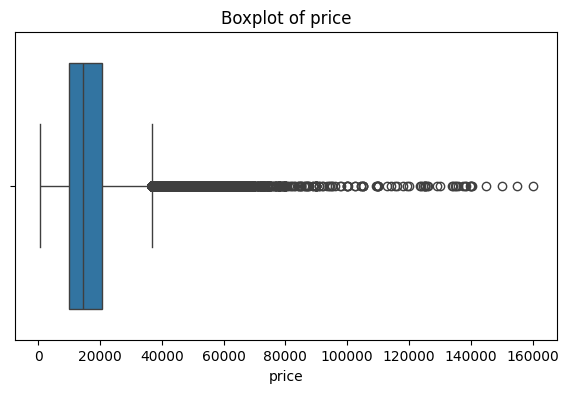

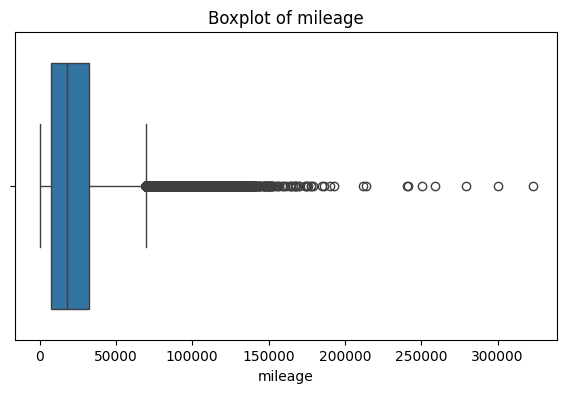

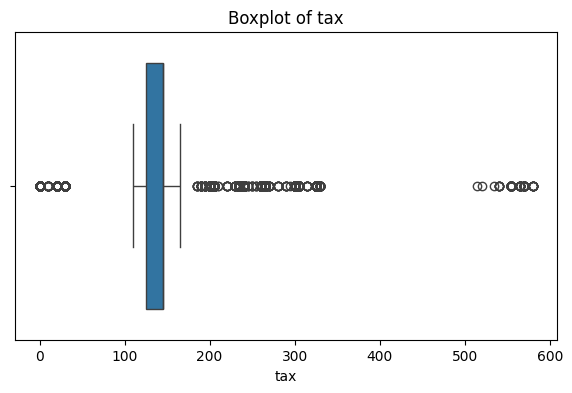

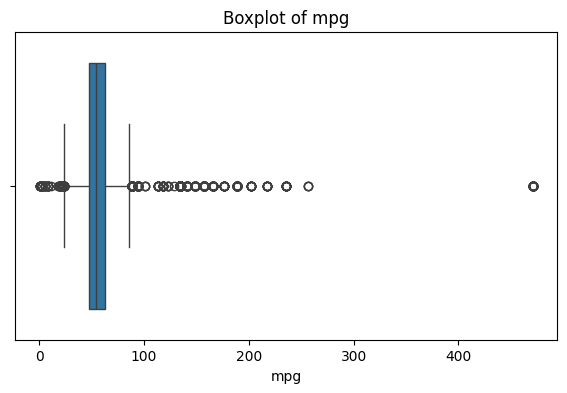

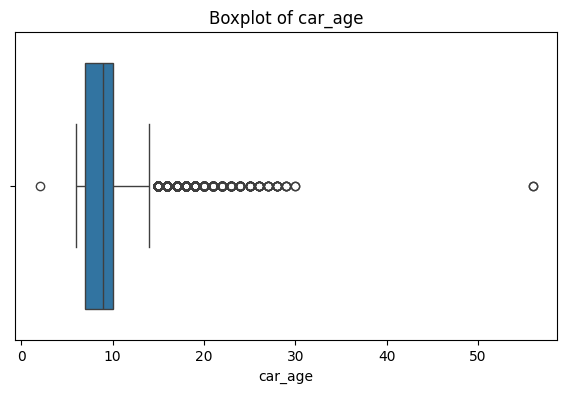

In [47]:
# Boxplots to visually check for outliers
outlier_columns = ["price", "mileage", "tax", "mpg", "car_age"]

for col in outlier_columns:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=cars[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

The `price` column has some very high values, with the 99th percentile at about 52,447 while the maximum price is 159,999. This suggests that a small number of cars are much more expensive than the majority of the dataset.

The `mileage` column also contains outliers. Most cars are below about 95,434 miles at the 99th percentile, but the maximum mileage is 323,000 miles. This shows that some cars have much higher mileage than normal.

The `mpg` column has a maximum value of 470.8, which is much higher than the 99th percentile value of 85.6. This may be caused by electric or hybrid vehicles, or unusual records in the dataset. The `car_age` column also contains a few older vehicles, with the maximum age being 56 years, while 99% of cars are 16 years old or younger.

These outliers were not removed immediately because they may represent real cars, such as luxury cars, high-mileage cars, electric/hybrid cars, or classic vehicles. However, they will need to be considered later when choosing a normalisation method, because extreme values can affect the final composite index.

In [48]:
outlier_columns = ["price", "mileage", "tax", "mpg", "car_age"]

for col in outlier_columns:
    lower = cars[col].quantile(0.01)
    upper = cars[col].quantile(0.99)
    
    below_lower = (cars[col] < lower).sum()
    above_upper = (cars[col] > upper).sum()
    
    print(f"{col}")
    print(f"Lower limit (1%): {lower}")
    print(f"Upper limit (99%): {upper}")
    print(f"Values below lower limit: {below_lower}")
    print(f"Values above upper limit: {above_upper}")
    print()

price
Lower limit (1%): 3995.0
Upper limit (99%): 52446.919999999984
Values below lower limit: 971
Values above upper limit: 978

mileage
Lower limit (1%): 11.0
Upper limit (99%): 95433.80999999998
Values below lower limit: 972
Values above upper limit: 978

tax
Lower limit (1%): 0.0
Upper limit (99%): 265.0
Values below lower limit: 0
Values above upper limit: 882

mpg
Lower limit (1%): 29.7
Upper limit (99%): 85.6
Values below lower limit: 922
Values above upper limit: 906

car_age
Lower limit (1%): 6.0
Upper limit (99%): 16.0
Values below lower limit: 1
Values above upper limit: 962



The outliers were not removed immediately because they may still represent real vehicles. However, they were noted because extreme values can affect the normalisation stage and may influence the final composite index.

## Data Label Encoding

In [54]:
# Get list of categorical variables
categorical_columns = cars.select_dtypes(include=["object", "string"]).columns

categorical_columns


Index(['model', 'transmission', 'fuel_type', 'manufacturer'], dtype='str')

In [57]:
# Create a summary of fuel types using average MPG and tax
fuel_summary = cars.groupby("fuel_type")[["mpg", "tax"]].mean()

fuel_summary


,mpg,tax
fuel_type,,
Diesel,58.25,114.45
Electric,297.07,22.50
Hybrid,88.98,71.90
Other,85.76,103.64
Petrol,50.85,127.22


In [62]:
# Function for normalising where higher values are better
def normalise(series):
    return (series - series.min()) / (series.max() - series.min())

# Function for normalising where lower values are better
def reverse_normalise(series):
    return 1 - ((series - series.min()) / (series.max() - series.min()))

# Higher MPG is better
fuel_summary["mpg_score"] = normalise(fuel_summary["mpg"])

# Lower tax is better
fuel_summary["tax_score"] = reverse_normalise(fuel_summary["tax"])

# Combine into fuel type score
fuel_summary["fuel_type_score"] = (
    fuel_summary["mpg_score"] * 0.7 +
    fuel_summary["tax_score"] * 0.3
)

fuel_summary

,mpg,tax,mpg_score,tax_score,fuel_type_score
fuel_type,,,,,
Diesel,58.25,114.45,0.03,0.12,0.06
Electric,297.07,22.50,1.00,1.00,1.00
Hybrid,88.98,71.90,0.15,0.53,0.27
Other,85.76,103.64,0.14,0.23,0.17
Petrol,50.85,127.22,0.00,0.00,0.00


In [63]:
fuel_score_map = fuel_summary["fuel_type_score"].to_dict()

cars["fuel_type_score"] = cars["fuel_type"].map(fuel_score_map)

cars[["fuel_type", "fuel_type_score"]].drop_duplicates().sort_values("fuel_type_score", ascending=False)

,fuel_type,fuel_type_score
12403,Electric,1.00
5,Hybrid,0.27
445,Other,0.17
2,Diesel,0.06
0,Petrol,0.00


In [69]:
transmission_encoded = pd.get_dummies(
    cars["transmission"],
    prefix="transmission",
    drop_first=False,
    dtype=int
)

cars_multi = cars[[
    "price",
    "mileage",
    "tax",
    "mpg",
    "car_age",
    "fuel_type_score"
]].copy()

cars_multi = pd.concat([cars_multi, transmission_encoded], axis=1)

cars_multi.head()

,price,mileage,tax,mpg,car_age,fuel_type_score,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto
0,7495,11630,145,60.10,9,0.00,0,1,0,0
1,10989,9200,145,58.90,9,0.00,0,1,0,0
2,27990,1614,145,49.60,7,0.06,0,0,0,1
3,12495,30960,150,62.80,9,0.06,0,1,0,0
4,7999,19353,125,54.30,9,0.00,0,1,0,0


## Multivariate Analysis
